In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 20)

In [2]:
stops = pd.read_csv('data/stops.txt')
stops.head()

,stop_id,stop_code,stop_name,stop_lat,stop_lon,zone_id,stop_url,location_type,parent_station,wheelchair_boarding,intersection_code,reference_place,stop_name_short,stop_place
0,11tbro,NaN,11th Ave & Broadway,32.716268,-117.154649,NaN,NaN,1,NaN,0,NaN,NaN,11tbro,NaN
1,12tS,NaN,12th & Imperial Station,32.706002,-117.153378,NaN,NaN,1,NaN,0,NaN,NaN,12tS,NaN
2,imtS,NaN,12th & Imperial Station Bayside,32.705229,-117.154318,NaN,NaN,1,NaN,0,NaN,NaN,imtS,NaN
3,imp12,NaN,12th & Imperial Transit Center,32.705685,-117.152875,NaN,NaN,1,NaN,0,NaN,NaN,imp12,NaN
4,24tS,NaN,24th Street Station,32.661854,-117.108017,NaN,NaN,1,NaN,0,NaN,NaN,24tS,NaN


In [3]:
print("Total stops:", len(stops))
print("\nMissing values per column:")
print(stops.isnull().sum())
print("\nDuplicate rows:", stops.duplicated().sum())
print("\nLat range:", stops['stop_lat'].min(), "to", stops['stop_lat'].max())
print("Lon range:", stops['stop_lon'].min(), "to", stops['stop_lon'].max())

Total stops: 4373

Missing values per column:
stop_id                   0
stop_code               103
stop_name                 0
stop_lat                  0
stop_lon                  0
zone_id                4373
stop_url               4373
location_type             0
parent_station         4112
wheelchair_boarding       0
intersection_code       227
reference_place        4352
stop_name_short           0
stop_place             3160
dtype: int64

Duplicate rows: 0

Lat range: 32.54281914 to 33.2568868
Lon range: -117.27792366 to -116.18445788


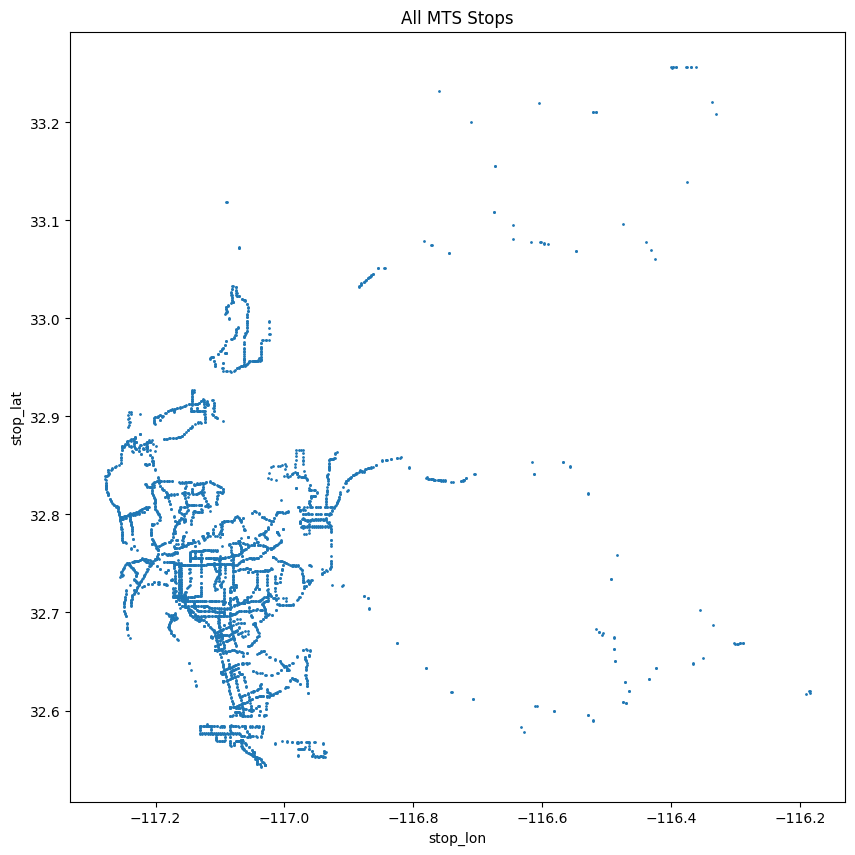

In [4]:
stops.plot.scatter(x='stop_lon', y='stop_lat', s=1, figsize=(10, 10))
plt.title('All MTS Stops')
plt.show()

## Observations: stops.txt
- 4,373 total stops
- All have valid stop_id, stop_name, lat, and lon (no missing) 
- Several columns are entirely empty (zone_id, stop_url) — drop 
- parent_station 94% missing —  applies to multi-platform stations
- 0 duplicate rows
- Coordinates within San Diego County bounds

In [5]:
routes = pd.read_csv('data/routes.txt')
routes.head()

,route_id,agency_id,route_short_name,route_long_name,route_type,route_url,route_color,route_text_color,route_group,route_pattern1,route_pattern2
0,1,MTS,1,Fashion Valley - La Mesa,3,https://www.sdmts.com/schedules-real-time?frag...,000099,FFFFFF,SBMF,1-W,1-E
1,2,MTS,2,Downtown San Diego - 30th & Adams,3,https://www.sdmts.com/schedules-real-time?frag...,000099,FFFFFF,SDTC,2-S1,2-N1
2,3,MTS,3,UCSD Hospital - Euclid Transit Center,3,https://www.sdmts.com/schedules-real-time?frag...,000099,FFFFFF,SBMF,3-N,3-S
3,4,MTS,4,12th & Imperial Trolley - Lomita Village,3,https://www.sdmts.com/schedules-real-time?frag...,000099,FFFFFF,SDTC,4-E,4-W
4,5,MTS,5,Downtown San Diego - Euclid Transit Center,3,https://www.sdmts.com/schedules-real-time?frag...,000099,FFFFFF,SBMF,5-E,5-W


In [6]:
print("Total routes:", len(routes))
print("\nMissing values:")
print(routes.isnull().sum())
print("\nDuplicates:", routes.duplicated().sum())

Total routes: 105

Missing values:
route_id             0
agency_id            0
route_short_name     2
route_long_name      0
route_type           0
route_url            0
route_color          0
route_text_color     0
route_group         10
route_pattern1       2
route_pattern2      21
dtype: int64

Duplicates: 0


In [7]:
trips = pd.read_csv('data/trips.txt')
stop_times = pd.read_csv('data/stop_times.txt')
calendar = pd.read_csv('data/calendar.txt')
shapes = pd.read_csv('data/shapes.txt')

print(f"trips:       {trips.shape}")
print(f"stop_times:  {stop_times.shape}")
print(f"calendar:    {calendar.shape}")
print(f"shapes:      {shapes.shape}")

print("\n--- Routes already loaded ---")
print(f"routes:      {routes.shape}")  

trips:       (22705, 12)
stop_times:  (671017, 10)
calendar:    (44, 11)
shapes:      (97051, 5)

--- Routes already loaded ---
routes:      (105, 11)


/var/folders/lh/p6zh0fy17c7_3q1lh8vxdhrw0000gn/T/ipykernel_43292/1782879397.py:2: DtypeWarning: Columns (0: stop_headsign) have mixed types. Specify dtype option on import or set low_memory=False.
  stop_times = pd.read_csv('data/stop_times.txt')


In [8]:
# Route types in GTFS are coded numerically:
# 0 = Tram/Trolley, 1 = Subway, 2 = Rail, 3 = Bus, 4 = Ferry
route_type_map = {0: 'Trolley', 1: 'Subway', 2: 'Rail', 3: 'Bus', 4: 'Ferry'}
routes['route_type_name'] = routes['route_type'].map(route_type_map)

print("--- Route Type Breakdown ---")
print(routes['route_type_name'].value_counts())

print("\n--- Sample routes from each type ---")
for rtype in routes['route_type_name'].unique():
    sample = routes[routes['route_type_name']==rtype][['route_short_name','route_long_name']].head(3)
    print(f"\n{rtype}:")
    print(sample.to_string(index=False))

--- Route Type Breakdown ---
route_type_name
Bus        99
Trolley     5
Ferry       1
Name: count, dtype: int64

--- Sample routes from each type ---

Bus:
route_short_name                       route_long_name
               1              Fashion Valley - La Mesa
               2     Downtown San Diego - 30th & Adams
               3 UCSD Hospital - Euclid Transit Center

Trolley:
route_short_name            route_long_name
            Blue           San Ysidro - UTC
          Copper          Santee - El Cajon
           Green El Cajon - 12th & Imperial

Ferry:
route_short_name route_long_name
             NaN  Coronado Ferry


In [9]:
# How many trips does each route run? More trips = more frequent service
trips_per_route = trips.groupby('route_id').size().reset_index(name='trip_count')
trips_per_route = trips_per_route.merge(
    routes[['route_id', 'route_short_name', 'route_long_name', 'route_type_name']],
    on='route_id'
)
trips_per_route = trips_per_route.sort_values('trip_count', ascending=False)

print("--- Top 10 busiest routes (by daily trip count) ---")
print(trips_per_route.head(10).to_string(index=False))

print("\n--- Bottom 10 routes (least frequent) ---")
print(trips_per_route.tail(10).to_string(index=False))

print(f"\nMean trips per route: {trips_per_route['trip_count'].mean():.0f}")
print(f"Median: {trips_per_route['trip_count'].median():.0f}")
print(f"Range: {trips_per_route['trip_count'].min()}-{trips_per_route['trip_count'].max()}")

--- Top 10 busiest routes (by daily trip count) ---
route_id  trip_count route_short_name                           route_long_name route_type_name
     227         750              227             Imperial Beach - Otay Mesa TC             Bus
     215         714              215                            Mid-City Rapid             Bus
       7         693                7   Downtown San Diego - University/College             Bus
     510         627             Blue                          San Ysidro - UTC         Trolley
     929         486              929     12th & Imperial - Iris Transit Center             Bus
       8         477                8                   Old Town - Balboa Av TC             Bus
      12         468               12           12th & Imperial - Skyline Hills             Bus
      13         460               13 Kaiser Hospital  - 24th St Transit Center             Bus
     530         458            Green                El Cajon - 12th & Imperial     